In [19]:
import pandas as pd
import pickle
import pandas as pd
import numpy as np

from cobrame.solve.algorithms import binary_search
from cobrame.solve.symbolic import compile_expressions
from cobra import Reaction, Metabolite

import cobra 
import cobrame 
import Bio 
import pickle 
import ecolime
from os.path import dirname, abspath, join


In [20]:
ecoli_dir = dirname(abspath(ecolime.__file__)) 
model_file = join(ecoli_dir, "me_models", "iJL1678b.pickle") 


with open(model_file, "rb") as f:
    base_me = pickle.load(f)


In [ ]:
ntr1 = pd.read_csv('imodulon_genes/e_coli_precise_mg1655_NtrC-1_genes.csv')
ntr2 = pd.read_csv('imodulon_genes/e_coli_precise_mg1655_NtrC-2_genes.csv')
gadx = pd.read_csv('imodulon_genes/e_coli_precise_mg1655_GadX_genes.csv')
arca1 = pd.read_csv('imodulon_genes/e_coli_precise_mg1655_ArcA-1_genes.csv')
arca2 = pd.read_csv('imodulon_genes/e_coli_precise_mg1655_ArcA-2_genes.csv')
fnr1 = pd.read_csv('imodulon_genes/e_coli_precise_mg1655_Fnr-1_genes.csv')
fnr2 = pd.read_csv('imodulon_genes/e_coli_precise_mg1655_Fnr-2_genes.csv')


ntr1_genes = ntr1['gene_locus'].unique().tolist()
ntr2_genes = ntr2['gene_locus'].unique().tolist()
gadx_genes = gadx['gene_locus'].unique().tolist()
arca1_genes = arca1['gene_locus'].unique().tolist()
arca2_genes = arca2['gene_locus'].unique().tolist()
fnr1_genes = fnr1['gene_locus'].unique().tolist()
fnr2_genes = fnr2['gene_locus'].unique().tolist()

In [22]:
gene_sets = {
    "Ntr1": ntr1_genes,
    "Ntr2": ntr2_genes,
    "GadX": gadx_genes,
    "ArcA1": arca1_genes,
    "ArcA2": arca2_genes,
    "Fnr1": fnr1_genes,
    "Fnr2": fnr2_genes
}

results = []

for name, genes in gene_sets.items():

    present = [
        gene for gene in genes
        if "translation_" + gene in base_me.reactions
    ]

    missing = [
        gene for gene in genes
        if "translation_" + gene not in base_me.reactions
    ]

    results.append({
        "iModulon": name,
        "total_genes": len(genes),
        "genes_in_ME": len(present),
        "genes_missing": len(missing),
        "fraction_in_ME": len(present) / len(genes)
    })
    
    
coverage_df = pd.DataFrame(results)

coverage_df

,iModulon,total_genes,genes_in_ME,genes_missing,fraction_in_ME
0,Ntr1,43,28,15,0.651163
1,Ntr2,8,6,2,0.750000
2,GadX,19,5,14,0.263158
3,ArcA1,23,12,11,0.521739
4,ArcA2,37,29,8,0.783784
5,Fnr1,33,16,17,0.484848
6,Fnr2,37,18,19,0.486486


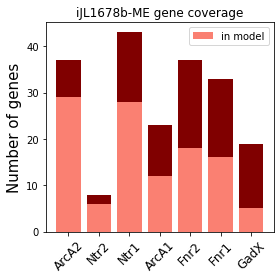

In [23]:
import matplotlib.pyplot as plt

df = coverage_df.sort_values("fraction_in_ME", ascending=False).reset_index(drop=True)
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(4,4))
ax.bar(x, df["total_genes"], color="maroon")
ax.bar(x, df["genes_in_ME"], color="salmon", label="in model")

ax.set_xticks(x)
ax.set_xticklabels(df["iModulon"], rotation=45,fontsize=12)
ax.set_ylabel("Number of genes",fontsize=15)
ax.set_title("iJL1678b-ME gene coverage")
ax.legend()

fig.tight_layout()
fig.savefig("imodulon_ME_coverage.png", dpi=300)
plt.show()

In [24]:
tpm_metadata = pd.read_excel(
    "sample_table_TPMcolumn_to_nitrogen_source.xlsx",
    engine="openpyxl"
)
tpm_metadata

,tpm_column,nitrogen_source,condition,replicate,group,Growth Rate (1/hr)
0,SNPV1_condition39_Rep1,NH4Cl,D-Glucose_NH4Cl,1,A,0.742
1,SNPV1_condition39_Rep2,NH4Cl,D-Glucose_NH4Cl,2,A,0.739
2,SNPV2_condition1_Rep1,NH4Cl,Glucose_NH4Cl,1,A,0.739
3,SNPV2_condition1_Rep2,NH4Cl,Glucose_NH4Cl,2,A,0.746
4,SNPV1_condition72_Rep1,Adenine,Glucose_Adenine,1,A,0.559
5,SNPV1_condition72_Rep2,Adenine,Glucose_Adenine,2,A,0.547
6,SNPV1_condition66_Rep1,L-Cys,Glucose_L-Cysteine,1,A,0.128
7,SNPV1_condition66_Rep2,L-Cys,Glucose_L-Cysteine,2,A,0.120
8,SNPV1_condition75_Rep1,Cytosine,Glucose_Cytosine,1,B,0.252
9,SNPV1_condition75_Rep2,Cytosine,Glucose_Cytosine,2,B,0.245


In [25]:
tpm = pd.read_csv('tpm_qc_nitrogen42_labeled.csv')
tpm

,gene,NH4Cl__SNPV1_condition39_Rep1,NH4Cl__SNPV1_condition39_Rep2,NH4Cl__SNPV2_condition1_Rep1,NH4Cl__SNPV2_condition1_Rep2,Adenine__SNPV1_condition72_Rep1,Adenine__SNPV1_condition72_Rep2,L-Cys__SNPV1_condition66_Rep1,L-Cys__SNPV1_condition66_Rep2,Cytosine__SNPV1_condition75_Rep1,...,L-Ala__SNPV1_condition62_Rep1,L-Ala__SNPV1_condition62_Rep2,L-Arg__SNPV1_condition63_Rep1,L-Arg__SNPV1_condition63_Rep2,GABA__SNPV1_condition60_Rep1,GABA__SNPV1_condition60_Rep2,L-Ser__SNPV1_condition70_Rep1,L-Ser__SNPV1_condition70_Rep2,Guanosine__SNPV1_condition76_Rep1,Guanosine__SNPV1_condition76_Rep2
0,b0002,1159.276852,1306.506642,1483.374781,1861.801521,855.989520,759.435861,3668.858977,3668.095880,1074.980689,...,1841.322764,1896.338678,800.173119,882.088196,347.859028,282.714057,1075.303674,993.573519,703.459952,773.761474
1,b0003,633.293526,851.600904,1070.181638,1363.621910,713.944784,836.665413,2133.004214,2269.050379,904.566157,...,1582.002491,1683.752335,1031.636849,1150.279022,343.850450,336.716747,1254.003559,1218.235669,601.454913,559.451014
2,b0004,636.657455,905.512803,893.548665,1087.827157,634.955568,705.603881,1647.524371,1751.748446,753.837711,...,1210.532365,1288.206659,833.926306,922.906429,300.117972,264.300870,1384.815066,1479.714241,416.045441,398.606819
3,b0005,105.293505,80.491216,71.718214,60.931956,51.367192,44.316875,126.925388,124.218261,51.370392,...,121.344931,122.916537,99.920487,96.898399,31.169277,29.289954,99.381816,103.941331,23.320623,18.318176
4,b0006,64.071307,48.588669,55.109666,76.223760,67.357462,50.913600,62.898909,60.945904,57.732570,...,46.382812,49.249628,23.270239,24.411662,64.808733,55.978870,54.157312,43.659857,20.742334,18.946394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4188,b4399,11.995335,12.328232,18.800056,25.014171,20.420712,24.304047,41.904887,47.657658,28.276593,...,25.140298,22.900044,34.203525,34.500930,24.921279,27.887119,23.008026,17.497492,14.114170,11.004516
4189,b4400,15.893970,14.766435,13.308535,17.023119,8.926616,9.673748,22.807120,23.197658,7.710378,...,14.269657,13.881250,18.520232,16.516773,14.804751,15.123942,11.639184,8.524805,9.352314,27.674374
4190,b4401,207.639596,241.654173,600.582428,461.961106,510.071918,429.291825,900.302218,849.894002,610.542156,...,791.511844,781.409444,1081.476125,1012.720035,772.330026,756.636721,643.301985,694.915592,846.922553,550.789627
4191,b4402,1.117322,2.931620,24.918107,19.446369,17.532242,7.300985,17.744700,11.715727,20.346375,...,21.299908,13.320093,18.816927,20.101264,6.791838,10.516340,16.478357,7.217810,11.335884,4.539423


In [26]:
# ----------------------------------------------------------
# Average replicate TPMs, one column per nitrogen source
# ----------------------------------------------------------

# tpm columns are named '<source>__<tpm_column>', so map each
# sample back to its nitrogen source through the metadata table
col_to_source = dict(
    zip(
        tpm_metadata["tpm_column"],
        tpm_metadata["nitrogen_source"]
    )
)

tpm_indexed = tpm.set_index("gene")

sample_to_source = {
    col: col_to_source[col.split("__", 1)[-1]]
    for col in tpm_indexed.columns
}

# mean across all replicates (and conditions) of a given source
tpm_by_source = (
    tpm_indexed
    .rename(columns=sample_to_source)
    .T
    .groupby(level=0)
    .mean()
    .T
)

# keep the metadata ordering of the sources
source_order = (
    tpm_metadata["nitrogen_source"]
    .drop_duplicates()
    .tolist()
)

tpm_by_source = tpm_by_source[source_order]

print(
    "Samples:", tpm_indexed.shape[1],
    "-> nitrogen sources:", tpm_by_source.shape[1]
)

tpm_by_source

Samples: 42 -> nitrogen sources: 20


,NH4Cl,Adenine,L-Cys,Cytosine,Cytidine,Putrescine,L-Pro,Adenosine,L-Asn,GlcNAc,Neu5Ac,Glycine,L-Orn,L-Asp,D-Ala,L-Ala,L-Arg,GABA,L-Ser,Guanosine
gene,,,,,,,,,,,,,,,,,,,,
b0002,1452.739949,807.712691,3668.477429,1189.297607,1416.821032,726.247342,1571.540602,1210.587389,1145.105477,1812.716410,2838.010797,1992.237003,423.789321,694.788479,991.174448,1868.830721,841.130657,315.286543,1034.438597,738.610713
b0003,979.674494,775.305099,2201.027297,991.076416,1030.883920,618.924735,1610.111252,992.712237,964.269949,1389.700289,2231.697049,1785.294203,383.977124,629.376057,935.600696,1632.877413,1090.957935,340.283598,1236.119614,580.452964
b0004,880.886520,670.279724,1699.636408,800.664448,902.391655,526.487113,1205.251439,820.765173,841.902267,1169.952998,1875.229575,1309.006182,292.153874,443.250831,804.668650,1249.369512,878.416367,282.209421,1432.264653,407.326130
b0005,79.608723,47.842034,125.571824,47.670575,48.909666,40.525193,85.350646,57.546487,57.085822,72.432807,121.065434,57.064159,21.801175,26.471742,61.498879,122.130734,98.409443,30.229615,101.661574,20.819400
b0006,60.998350,59.135531,61.922406,57.876241,59.964104,53.030248,45.956731,62.201281,56.490255,67.933778,52.642066,54.723359,41.312481,50.651329,58.747963,47.816220,23.840951,60.393801,48.908585,19.844364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
b4399,17.034449,22.362379,44.781272,27.382784,23.508501,26.186170,18.691615,23.477313,15.504157,18.739157,18.419038,19.454019,18.911224,17.176853,19.131592,24.020171,34.352227,26.404199,20.252759,12.559343
b4400,15.248015,9.300182,23.002389,12.118988,7.023145,10.395325,10.421499,7.438150,9.854366,7.455269,10.175140,14.491690,14.358067,11.926679,12.279938,14.075453,17.518502,14.964347,10.081995,18.513344
b4401,377.959326,469.681872,875.098110,590.704228,579.929756,714.752252,889.754727,1232.686226,1822.371074,1419.331009,1152.083984,1508.244254,2328.505163,1540.263584,656.495160,786.460644,1047.098080,764.483374,669.108789,698.856090


In [ ]:
imodulon_genes = {
    "NtrC-1": ntr1_genes,
    "NtrC-2": ntr2_genes,
    "GadX": gadx_genes,
    "ArcA-1": arca1_genes,
    "ArcA-2": arca2_genes,
    "Fnr-1": fnr1_genes,
    "Fnr-2": fnr2_genes
}

sector_fraction = {}

for sector, genes in imodulon_genes.items():

    genes_in_tpm = [
        g for g in genes
        if g in tpm_by_source.index
    ]

    sector_fraction[sector] = (
        tpm_by_source.loc[genes_in_tpm].sum(axis=0)
        / tpm_by_source.sum(axis=0)
    )

sector_fraction = pd.DataFrame(
    sector_fraction
).T


def gene_to_tx_reactions(me, gene):

    rna_id = "RNA_" + gene

    try:
        rna = me.metabolites.get_by_id(rna_id)
    except KeyError:
        return []

    return [
        rxn.id
        for rxn in rna.reactions
        if type(rxn).__name__ == "TranscriptionReaction"
    ]
    

sector_tus = {}

for sector, genes in imodulon_genes.items():

    tus = set()

    for gene in genes:

        for tx in gene_to_tx_reactions(
            base_me,
            gene
        ):
            tus.add(tx)

    sector_tus[sector] = sorted(tus)

    print(
        sector,
        "TUs represented:",
        len(tus)
    )

NtrC-1 TUs represented: 18
NtrC-2 TUs represented: 9
GadX TUs represented: 7
ArcA-1 TUs represented: 17
ArcA-2 TUs represented: 30
Fnr-1 TUs represented: 22
Fnr-2 TUs represented: 12


In [28]:
sector_fraction

,NH4Cl,Adenine,L-Cys,Cytosine,Cytidine,Putrescine,L-Pro,Adenosine,L-Asn,GlcNAc,Neu5Ac,Glycine,L-Orn,L-Asp,D-Ala,L-Ala,L-Arg,GABA,L-Ser,Guanosine
NtrC-1,0.001295,0.001252,0.010870,0.035712,0.051321,0.027466,0.036960,0.037550,0.027076,0.031439,0.020952,0.032627,0.034174,0.025979,0.013779,0.025331,0.034024,0.024234,0.006235,0.067214
NtrC-2,0.001288,0.001145,0.000373,0.011540,0.021600,0.014036,0.011736,0.020292,0.012096,0.017570,0.009113,0.014091,0.010336,0.011278,0.009162,0.012412,0.010036,0.011869,0.007107,0.011393
GadX,0.001583,0.002220,0.017867,0.002838,0.004357,0.006072,0.019569,0.048626,0.102612,0.068550,0.057688,0.086825,0.089460,0.097063,0.022681,0.077407,0.062841,0.040803,0.048988,0.030367
ArcA-1,0.003175,0.002241,0.003163,0.002738,0.003218,0.005433,0.002950,0.002003,0.001319,0.001664,0.001407,0.002089,0.003856,0.001479,0.003838,0.001621,0.001620,0.012740,0.004479,0.003870
ArcA-2,0.022438,0.027844,0.022809,0.026859,0.029996,0.025176,0.017760,0.023478,0.014988,0.017554,0.022125,0.016854,0.012853,0.012426,0.023568,0.015510,0.010270,0.018578,0.015243,0.008982
Fnr-1,0.003760,0.004096,0.008632,0.003315,0.003828,0.009069,0.004920,0.002481,0.002724,0.002578,0.002723,0.004230,0.005826,0.006133,0.011434,0.002365,0.005194,0.051345,0.020554,0.029164
Fnr-2,0.001489,0.002399,0.002162,0.000987,0.001069,0.006344,0.001514,0.000811,0.000787,0.000883,0.001103,0.001218,0.002201,0.001422,0.006622,0.000714,0.001399,0.020872,0.016468,0.007351


In [29]:
def create_tx_sum(me, group_name, tx_list):

    rxn_sum = Reaction(group_name)
    me.add_reaction(rxn_sum)

    cons = Metabolite("sum_" + group_name)
    cons._constraint_sense = "E"
    cons._bound = 0

    me.add_metabolites([cons])

    for rid in tx_list:
        if rid in me.reactions:
            me.reactions.get_by_id(rid).add_metabolites(
                {cons: 1.0},
                combine=True
            )

    rxn_sum.add_metabolites({
        cons: -1.0
    })
    
    
def set_tx_fraction(me, sector_name, total_name, fraction):

    cons = Metabolite(
        sector_name + "_fraction"
    )

    cons._constraint_sense = "E"
    cons._bound = 0

    me.add_metabolites([cons])

    me.reactions.get_by_id(
        sector_name
    ).add_metabolites({
        cons: 1.0
    })

    me.reactions.get_by_id(
        total_name
    ).add_metabolites({
        cons: -fraction
    })

In [30]:
# ----------------------------------------------------------
# Nitrogen sources
# ----------------------------------------------------------

nitrogen_exchange_map = {
    'NH4Cl': 'EX_nh4_e',
    'Adenine': 'EX_ade_e',
    'L-Cys': 'EX_cys__L_e',
    'Cytosine': 'EX_csn_e',
    'Cytidine': 'EX_cytd_e',
    'Putrescine': 'EX_ptrc_e',
    'L-Pro': 'EX_pro__L_e',
    'Adenosine': 'EX_adn_e',
    'L-Asn': 'EX_asn__L_e',
    'GlcNAc': 'EX_acgam_e',
    'Glycine': 'EX_gly_e',
    'L-Orn': 'EX_orn_e',
    'L-Asp': 'EX_asp__L_e',
    'D-Ala': 'EX_ala__D_e',
    'L-Ala': 'EX_ala__L_e',
    'L-Arg': 'EX_arg__L_e',
    'GABA': 'EX_4abut_e',
    'L-Ser': 'EX_ser__L_e',
    'Guanosine': 'EX_gsn_e'
}


# ----------------------------------------------------------
# Number of N atoms in each source
# ----------------------------------------------------------

nitrogen_atoms = {
    'NH4Cl': 1,
    'Adenine': 5,
    'L-Cys': 1,
    'Cytosine': 3,
    'Cytidine': 3,
    'Putrescine': 2,
    'L-Pro': 1,
    'Adenosine': 5,
    'L-Asn': 2,
    'GlcNAc': 1,
    'Glycine': 1,
    'L-Orn': 2,
    'L-Asp': 1,
    'D-Ala': 1,
    'L-Ala': 1,
    'L-Arg': 4,
    'GABA': 1,
    'L-Ser': 1,
    'Guanosine': 5
}


# ----------------------------------------------------------
# Nitrogen-source groups
# ----------------------------------------------------------

group_A_subs = [
    'NH4Cl',
    'Adenine',
    'L-Cys'
]

group_B_subs = [
    'Cytosine',
    'Cytidine'
]

group_C_subs = [
    'Putrescine',
    'L-Pro',
    'Adenosine',
    'L-Asn',
    'GlcNAc',
    'Glycine',
    'L-Orn',
    'L-Asp',
    'D-Ala',
    'L-Ala',
    'L-Arg'
]

group_D_subs = [
    'GABA',
    'L-Ser',
    'Guanosine'
]


In [ ]:
growth_rates = {}
flux_dict = {}

for nitrogen_source, exchange_id in nitrogen_exchange_map.items():

    print("\n", nitrogen_source)

    # fresh model
    me = pickle.loads(
        pickle.dumps(base_me)
    )

    # close all tested N sources
    for ex in nitrogen_exchange_map.values():
        if ex in me.reactions:
            me.reactions.get_by_id(ex).lower_bound = 0

    # glucose
    me.reactions.get_by_id(
        "EX_glc__D_e"
    ).lower_bound = -10

    # open current N source
    me.reactions.get_by_id(
        exchange_id
    ).lower_bound = (
        -8 / nitrogen_atoms[nitrogen_source]
    )

    # all transcription reactions
    all_tx = [
        r.id
        for r in me.reactions
        if type(r).__name__ == "TranscriptionReaction"
    ]

    # total transcription
    create_tx_sum(
        me,
        "total_transcription",
        all_tx
    )

    # add each iModulon sector
    for sector, tus in sector_tus.items():

        sector_name = "tx_" + sector

        create_tx_sum(
            me,
            sector_name,
            tus
        )

        phi = sector_fraction.loc[
            sector,
            nitrogen_source
        ]

        set_tx_fraction(
            me,
            sector_name,
            "total_transcription",
            phi
        )

    # solve
    try:

        binary_search(
            me,
            min_mu=0.01,
            max_mu=1.0,
            mu_accuracy=1e-2,
            solver="soplex",
            verbose=False
        )

        mu_max = me.solution.f

        growth_rates[
            nitrogen_source
        ] = mu_max

        flux_dict[
            nitrogen_source
        ] = me.solution.x_dict.copy()

        print("Growth =", mu_max)

    except Exception as e:

        growth_rates[
            nitrogen_source
        ] = np.nan

        print("FAILED:", e)


 NH4Cl
Growth = 0.7834375

 Adenine
Growth = 0.806640625

 L-Cys
Growth = 0.7757031249999999

 Cytosine
Growth = 0.7757031249999999

 Cytidine
Growth = 0.7834375

 Putrescine
Growth = 0.7834375

 L-Pro
Growth = 0.760234375

 Adenosine
Growth = 0.791171875

 L-Asn
Growth = 0.7757031249999999

 GlcNAc
Growth = 0.760234375

 Glycine
Growth = 0.760234375

 L-Orn
Growth = 0.7834375

 L-Asp


In [ ]:
growth_df = pd.DataFrame.from_dict(
    growth_rates,
    orient="index",
    columns=["max_growth_rate"]
)

fluxes = pd.DataFrame(
    flux_dict
)

display(growth_df)

In [ ]:
group_A_allocation_genes = []

group_B_allocation_genes = (
    ntr1_genes
    + ntr2_genes
)

group_C_allocation_genes = (
    ntr1_genes
    + ntr2_genes
    + gadx_genes
)

group_D_allocation_genes = (
    ntr1_genes
    + ntr2_genes
    + gadx_genes
    + arca1_genes
    + arca2_genes
    + fnr1_genes
    + fnr2_genes
)


# Remove duplicates
group_A_allocation_genes = list(set(group_A_allocation_genes))
group_B_allocation_genes = list(set(group_B_allocation_genes))
group_C_allocation_genes = list(set(group_C_allocation_genes))
group_D_allocation_genes = list(set(group_D_allocation_genes))

In [ ]:
def get_group_and_genes(substrate):

    if substrate in group_A_subs:
        return "A", group_A_allocation_genes

    elif substrate in group_B_subs:
        return "B", group_B_allocation_genes

    elif substrate in group_C_subs:
        return "C", group_C_allocation_genes

    elif substrate in group_D_subs:
        return "D", group_D_allocation_genes

    else:
        raise ValueError(
            substrate + " is not assigned to a group"
        )


In [ ]:
from cobrame import mu
from cobrame import Constraint
from cobra import Reaction

sector_per_growth = 0.1   # try 0.01, 0.02, 0.05, etc.

growth_rates = {}
flux_dict = {}
translation_flux_dict = {}
missing_gene_dict = {}
group_dict = {}

nitrogen_exchanges = list(
    nitrogen_exchange_map.values()
)

for nitrogen_source, exchange_id in nitrogen_exchange_map.items():

    if nitrogen_source in group_A_subs:
        continue

    print("\n" + "=" * 60)
    print("Nitrogen source:", nitrogen_source)

    me = pickle.loads(
        pickle.dumps(base_me)
    )

    group, genes_to_force = get_group_and_genes(
        nitrogen_source
    )

    group_dict[nitrogen_source] = group

    print("Group:", group)
    print("Genes in sector:", len(genes_to_force))

    # -----------------------------------------
    # Close all tested nitrogen sources
    # -----------------------------------------

    for ex_id in nitrogen_exchanges:

        if ex_id in me.reactions:

            me.reactions.get_by_id(
                ex_id
            ).lower_bound = 0

    # glucose
    me.reactions.get_by_id(
        "EX_glc__D_e"
    ).lower_bound = -20

    # normalize nitrogen uptake by N atoms
    n_atoms = nitrogen_atoms[
        nitrogen_source
    ]

    nitrogen_bound = -10 / n_atoms

    me.reactions.get_by_id(
        exchange_id
    ).lower_bound = nitrogen_bound

    print(
        "Nitrogen uptake bound:",
        nitrogen_bound
    )

    # =========================================
    # Create protein-sector constraint
    # =========================================

    sector = Constraint(
        "stress_sector"
    )

    me.add_metabolites([sector])

    missing_genes = []
    forced_genes = []

    for gene in genes_to_force:

        rid = "translation_" + gene

        if rid not in me.reactions:

            missing_genes.append(gene)
            continue

        rxn = me.reactions.get_by_id(
            rid
        )

        # Get protein mass coefficient
        protein_mass = None

        for met, coeff in rxn.metabolites.items():

            if met.id == "protein_biomass":

                protein_mass = float(coeff)
                break

        if protein_mass is None:
            continue

        # Translation of this protein now
        # contributes to the stress sector
        rxn.add_metabolites({
            sector: protein_mass
        })

        forced_genes.append(gene)

    missing_gene_dict[
        nitrogen_source
    ] = missing_genes

    print(
        "Genes included:",
        len(forced_genes)
    )

    print(
        "Genes missing:",
        len(missing_genes)
    )

    # -----------------------------------------
    # Demand reaction for the whole sector
    # -----------------------------------------

    sector_demand = Reaction(
        "stress_sector_demand"
    )

    sector_demand.add_metabolites({
        sector: -1
    })

    # sector demand scales with growth
    sector_demand.lower_bound = (
        sector_per_growth * mu
    )

    sector_demand.upper_bound = 1000

    me.add_reaction(
        sector_demand
    )

    # =========================================
    # Solve
    # =========================================

    try:

        binary_search(
            me,
            min_mu=0.09,
            max_mu=0.9,
            mu_accuracy=1e-2,
            solver="soplex",
            verbose=False,
            debug=False
        )

        mu_max = me.solution.f

        growth_rates[
            nitrogen_source
        ] = mu_max

        print(
            "Maximum growth rate:",
            mu_max
        )

        flux_dict[
            nitrogen_source
        ] = me.solution.x_dict.copy()

        translation_flux_dict[
            nitrogen_source
        ] = (
            me.get_translation_flux().copy()
        )

    except Exception as e:

        print(
            "FAILED:",
            nitrogen_source
        )

        print(e)

        growth_rates[
            nitrogen_source
        ] = np.nan


# =============================================
# Results
# =============================================

growth_df = pd.DataFrame.from_dict(
    growth_rates,
    orient="index",
    columns=["max_growth_rate"]
)

growth_df.index.name = "nitrogen_source"

fluxes = pd.DataFrame(
    flux_dict
)

translation_fluxes = pd.DataFrame(
    translation_flux_dict
)

growth_df["group"] = [
    group_dict[x]
    for x in growth_df.index
]

print("\nGrowth rates:")
display(growth_df)

In [ ]:
growth_df.to_csv('growth_rates_after_constraining.csv')

In [ ]:
old_grs = pd.read_csv('ME_growth_rates_nitrogen_sources.csv')
old_grs

In [ ]:
import matplotlib.pyplot as plt

cmp = old_grs.set_index("nitrogen_source").join(
    growth_df["max_growth_rate"], lsuffix="_old", rsuffix="_new", how="inner")
cmp = cmp.sort_values("max_growth_rate_new")

x = np.arange(len(cmp))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, cmp["max_growth_rate_old"], 0.4, color="lightgray", label="no protein constraint")
ax.bar(x + 0.2, cmp["max_growth_rate_new"], 0.4, color="#4b8bd4", label="protein constrained")

ax.set_xticks(x)
ax.set_xticklabels(cmp.index, rotation=90)
ax.set_ylabel("Max growth rate (1/h)")
ax.set_title("Effect of protein sector constraint")
ax.legend()

fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(cmp["max_growth_rate_old"], cmp["max_growth_rate_new"], color="#4b8bd4")
ax.plot([0, 1], [0, 1], "--", color="gray")

for name, row in cmp.iterrows():
    ax.annotate(name, (row["max_growth_rate_old"], row["max_growth_rate_new"]),
                fontsize=7, xytext=(3, 3), textcoords="offset points")

ax.set_xlim(0.5, 1)
ax.set_ylim(0.5, 1)
ax.set_xlabel("Growth rate, unconstrained (1/h)")
ax.set_ylabel("Growth rate, protein constrained (1/h)")

fig.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 9, "font.family": "sans-serif",
                     "axes.linewidth": 0.8, "savefig.dpi": 300})

cmp = old_grs.set_index("nitrogen_source").join(
    growth_df, lsuffix="_old", rsuffix="_new", how="inner")

groups = sorted(cmp["group"].unique())
colors = {"B": "#4b8bd4", "C": "#e08214", "D": "#4daf4a"}

fig, ax = plt.subplots(figsize=(3.5, 3))
for i, g in enumerate(groups):
    sub = cmp[cmp["group"] == g]
    c = colors[g]
    for j, (col, filled, alpha) in enumerate([("max_growth_rate_old", False, 0.85),
                                              ("max_growth_rate_new", True, 0.3)]):
        x = i + (j - 0.5) * 0.3
        v = sub[col]
        ax.bar(x, v.median(), 0.28, color=c, alpha=alpha, edgecolor=c, linewidth=0.8)
        ax.scatter(np.random.normal(x, 0.03, len(v)), v, s=12, linewidth=0.8,
                   facecolors=c if filled else "none", edgecolors=c, zorder=3)

ax.scatter([], [], s=12, linewidth=0.8, facecolors="none", edgecolors="black",
           label="unconstrained")
ax.scatter([], [], s=12, color="black", label="protein constrained")

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(["Group " + g for g in groups])
ax.set_ylabel("Max growth rate (h$^{-1}$)")
ax.set_ylim(0, 1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(0.5,1))

fig.tight_layout()
fig.savefig("growth_rate_by_group.pdf", bbox_inches="tight")
fig.savefig("growth_rate_by_group.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
old_fluxes = pd.read_csv('ME_fluxes_nitrogen_sources.csv',index_col='Unnamed: 0')
old_fluxes

In [ ]:
[w for w in old_fluxes.index if 'transcription' in w]

In [ ]:
[r.id for r in base_me.reactions if "transcription" in r.id.lower()][:20]

In [ ]:
gene = "b0003"
rna_id = "RNA_" + gene

rna = base_me.metabolites.get_by_id(rna_id)

for rxn in rna.reactions:
    if type(rxn).__name__ == "TranscriptionReaction":
        print(rxn.id)